In [ ]:
import zipfile

zip_path = "/content/chilli.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/dataset"))

['Chilli Dataset']


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 123

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/Chilli Dataset",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 10987 files belonging to 5 classes.
Using 8790 files for training.


In [ ]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/Chilli Dataset",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10987 files belonging to 5 classes.
Using 2197 files for validation.


In [ ]:
class_names = train_dataset.class_names

print(class_names)
print("Number of Classes:", len(class_names))

['cercospora', 'healthy', 'mites_and_trips', 'nutritional', 'powdery mildew']
Number of Classes: 5


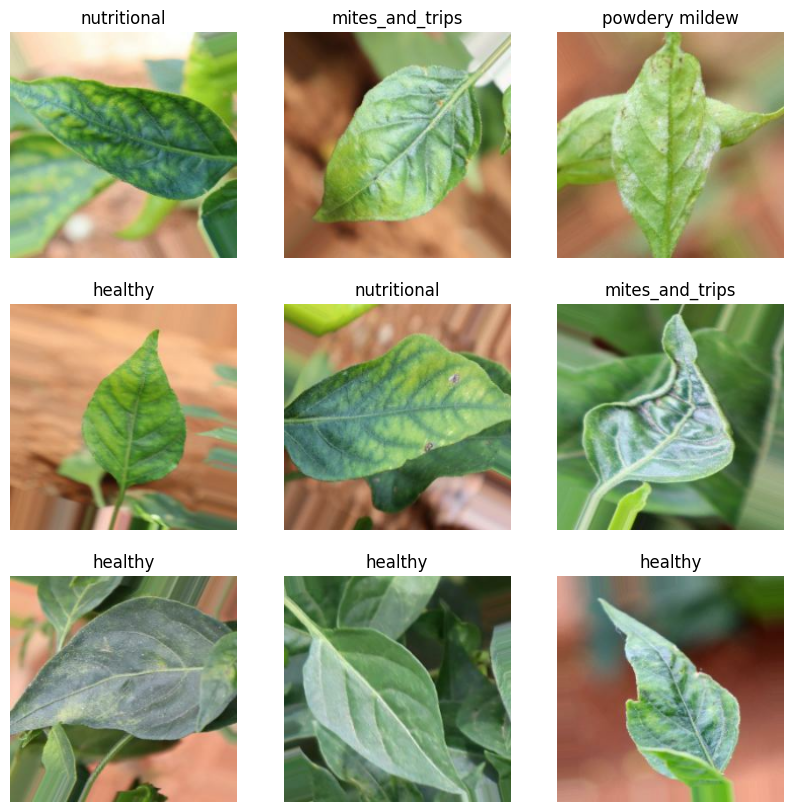

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

alexnet = Sequential([

    # Layer 1
    Conv2D(96, kernel_size=(11,11), strides=4,
           activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Layer 2
    Conv2D(256, kernel_size=(5,5),
           padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Layer 3
    Conv2D(384, kernel_size=(3,3),
           padding='same', activation='relu'),

    # Layer 4
    Conv2D(384, kernel_size=(3,3),
           padding='same', activation='relu'),

    # Layer 5
    Conv2D(256, kernel_size=(3,3),
           padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Flatten(),

    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
alexnet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,768,901 (178.41 MB)

 Trainable params: 46,768,197 (178.41 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
alexnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_alexnet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history_alexnet = alexnet.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2103 - loss: 3.0400
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_alexnet.keras

Epoch 1: finished saving model to best_alexnet.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.2231 - loss: 1.8854 - val_accuracy: 0.0000e+00 - val_loss: 1.6679 - learning_rate: 0.0010
Epoch 2/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2255 - loss: 1.6069
Epoch 2: val_accuracy did not improve from 0.00000
275/275 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.2289 - loss: 1.6071 - val_accuracy: 0.0000e+00 - val_loss: 1.6788 - learning_rate: 0.0010
Epoch 3/20
274/275 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2268 - loss: 1.6067
Epoch 3: val_accuracy did not improve from 0.00000
275/275 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.2301 - loss: 1.6068 - val_accuracy: 0.0000e+00 - val_loss: 1.6924 - learning_rate: 0.0010
Epoch 4/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step 

In [ ]:
import tensorflow as tf

tf.keras.backend.clear_session()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

alexnet_model = Sequential([

    # Layer 1
    Conv2D(96, (11,11),
           strides=4,
           activation='relu',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Layer 2
    Conv2D(256,
           (5,5),
           padding='same',
           activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Layer 3
    Conv2D(384,
           (3,3),
           padding='same',
           activation='relu'),

    # Layer 4
    Conv2D(384,
           (3,3),
           padding='same',
           activation='relu'),

    # Layer 5
    Conv2D(256,
           (3,3),
           padding='same',
           activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Flatten(),

    Dense(1024, activation='relu'),
    Dropout(0.5),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

In [ ]:
alexnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     6,554,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,830,597 (41.32 MB)

 Trainable params: 10,829,893 (41.31 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
alexnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_alexnet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history_alexnet = alexnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3679 - loss: 1.8930
Epoch 1: val_accuracy improved from None to 0.57442, saving model to best_alexnet.keras

Epoch 1: finished saving model to best_alexnet.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.4502 - loss: 1.3879 - val_accuracy: 0.5744 - val_loss: 1.2508 - learning_rate: 0.0010
Epoch 2/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5693 - loss: 1.0804
Epoch 2: val_accuracy did not improve from 0.57442
275/275 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.5924 - loss: 1.0378 - val_accuracy: 0.4474 - val_loss: 1.6121 - learning_rate: 0.0010
Epoch 3/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6612 - loss: 0.8978
Epoch 3: val_accuracy did not improve from 0.57442
275/275 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.6826 - loss: 0.8493 - val_accuracy: 0.4834 - val_loss: 2.8390 - learning_rate: 0.0010
Epoch 4/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'chilli.zip', 'best_alexnet.keras', 'dataset', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

shutil.copy(
    "/content/best_alexnet.keras",
    "/content/drive/MyDrive/best_alexnet.keras"
)

print("Model saved to Google Drive!")

Model saved to Google Drive!


In [ ]:
from google.colab import files

files.download("/content/best_alexnet.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import load_model

alexnet_model = load_model("/content/best_alexnet.keras")

In [ ]:
loss, accuracy = alexnet_model.evaluate(validation_dataset)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9995 - loss: 0.0020
Validation Loss : 0.001995443133637309
Validation Accuracy : 0.9995448589324951


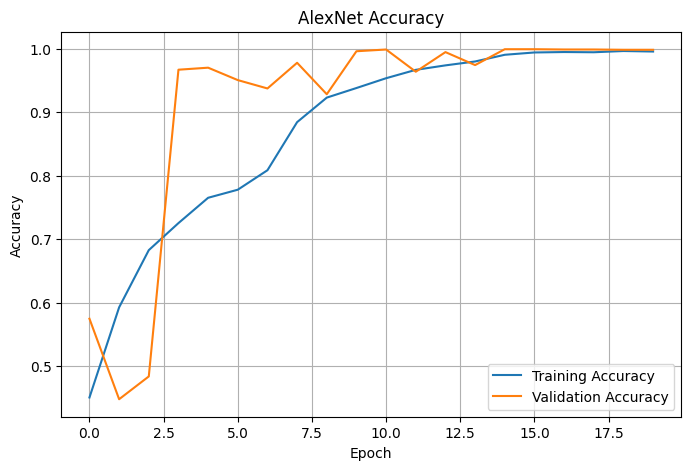

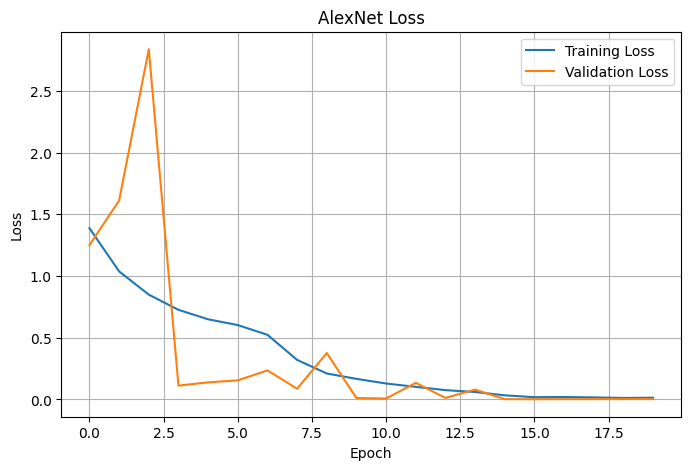

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_alexnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_alexnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('AlexNet Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_alexnet.history['loss'], label='Training Loss')
plt.plot(history_alexnet.history['val_loss'], label='Validation Loss')
plt.title('AlexNet Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#predictions
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = alexnet_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.9995448338643604
Precision : 1.0
Recall : 0.9995448338643604
F1 Score : 0.9997723608910406


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(train_dataset.class_names)
class_names = train_dataset.class_names

['cercospora', 'healthy', 'mites_and_trips', 'nutritional', 'powdery mildew']


In [ ]:
import numpy as np

print("Unique labels in y_true:", np.unique(y_true))
print("Unique labels in y_pred:", np.unique(y_pred))

print("Number of validation samples:", len(y_true))
print(train_dataset.class_names)
print(validation_dataset.class_names)
print(tf.data.experimental.cardinality(validation_dataset).numpy())

Unique labels in y_true: [3 4]
Unique labels in y_pred: [0 3 4]
Number of validation samples: 2197
['cercospora', 'healthy', 'mites_and_trips', 'nutritional', 'powdery mildew']
['cercospora', 'healthy', 'mites_and_trips', 'nutritional', 'powdery mildew']
69


In [ ]:
print(train_dataset)
print(validation_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


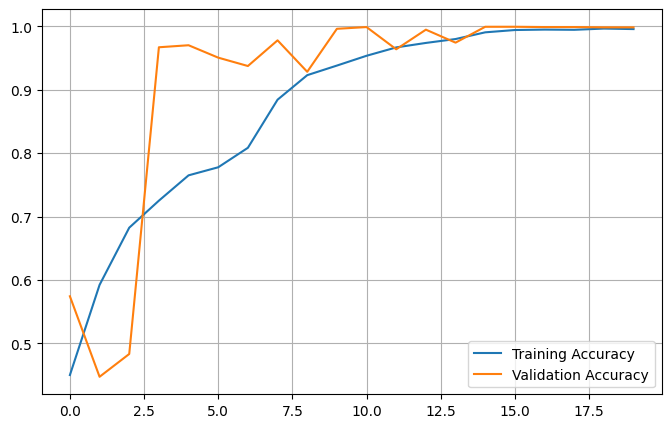

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_alexnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_alexnet.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.grid(True)

plt.savefig("alexnet_accuracy.png", dpi=300)

plt.show()

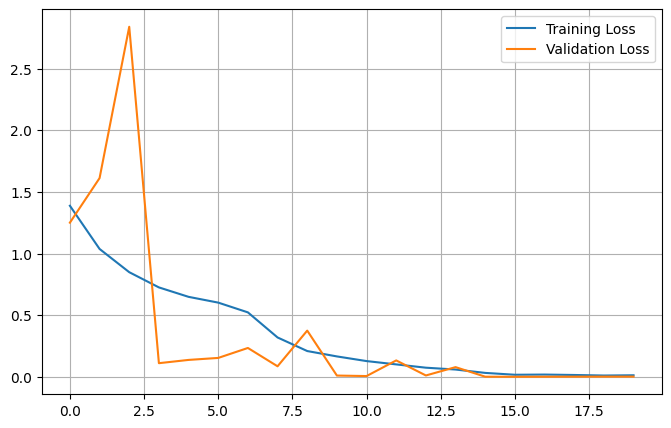

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_alexnet.history['loss'], label='Training Loss')
plt.plot(history_alexnet.history['val_loss'], label='Validation Loss')
plt.legend()
plt.grid(True)

plt.savefig("alexnet_loss.png", dpi=300)

plt.show()

In [ ]:
from google.colab import files

files.download("alexnet_accuracy.png")
files.download("alexnet_loss.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("alexnet_accuracy.png")
files.download("alexnet_loss.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

tf.keras.backend.clear_session()

In [ ]:
print(train_dataset)
print(validation_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(5, activation='softmax')(x)

googlenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [ ]:
googlenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,854,437 (87.18 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
googlenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_googlenet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history_googlenet = googlenet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3067 - loss: 13.5291
Epoch 1: val_accuracy improved from None to 0.71097, saving model to best_googlenet.keras

Epoch 1: finished saving model to best_googlenet.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 63s 170ms/step - accuracy: 0.3353 - loss: 4.9207 - val_accuracy: 0.7110 - val_loss: 1.1230 - learning_rate: 0.0010
Epoch 2/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3155 - loss: 1.4797
Epoch 2: val_accuracy improved from 0.71097 to 0.85708, saving model to best_googlenet.keras

Epoch 2: finished saving model to best_googlenet.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 49s 88ms/step - accuracy: 0.3358 - loss: 1.4516 - val_accuracy: 0.8571 - val_loss: 0.7450 - learning_rate: 0.0010
Epoch 3/20
274/275 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3324 - loss: 1.4293
Epoch 3: val_accuracy did not improve from 0.85708
275/275 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.3373 - loss: 1.4196 - val_accuracy: 0.7943 - va

In [ ]:
base_model.trainable = True

# Freeze most of the network and fine-tune only the last 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.optimizers import Adam

googlenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_finetune = googlenet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.3130 - loss: 1.5299
Epoch 1: val_accuracy did not improve from 0.85708
275/275 ━━━━━━━━━━━━━━━━━━━━ 73s 178ms/step - accuracy: 0.3819 - loss: 1.4494 - val_accuracy: 0.7906 - val_loss: 0.8067 - learning_rate: 1.0000e-05
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5130 - loss: 1.2490
Epoch 2: val_accuracy did not improve from 0.85708
275/275 ━━━━━━━━━━━━━━━━━━━━ 27s 98ms/step - accuracy: 0.5361 - loss: 1.1995 - val_accuracy: 0.7774 - val_loss: 0.7127 - learning_rate: 1.0000e-05
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5693 - loss: 1.0816
Epoch 3: val_accuracy did not improve from 0.85708

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
275/275 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.5931 - loss: 1.0459 - val_accuracy: 0.8198 - val_loss: 0.6077 - learning_rate: 1.0000e-05
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 

In [3]:
import zipfile

zip_path = "/content/chilli.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfu")

Dataset extracted successfu


In [4]:
import os

print(os.listdir("/content/dataset"))

['Chilli Dataset']
